In [1]:
# ==========================================================
# Celda 01 — Importación de paquetes
# ==========================================================
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

from joblib import Parallel, delayed

sys.path.insert(0, '../')
from codes.Quantum import *
from codes.CSPSA import *


In [8]:
# ==========================================================
# Celda 02 — Definición de funciones auxiliares
# ==========================================================

def complex2unitary( Z ):
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

def postprocessing(U):
    return complex2unitary( U )

def trineq(Us, Rho ):

    Us = np.array(Us)
    Us = postprocessing(Us)

    M_per_system = []
    for U in Us:
        M_each_qubit = []
        for u in U:
            M_each_qubit.append( np.outer(u,u.conj()) )
        M_per_system.append( M_each_qubit )
    probs = InnerProductMatrices( Rho, M_per_system ).real
    probs = probs.reshape(6*[2]) 

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1]*probs_clcr[1,0] 
                -probs_clcr[0,0]*probs_clcr[1,1] 
                -probs_clcr[0,1]*probs[1,0,0,1,1,0]
                -probs_clcr[0,1]*probs[1,1,0,0,1,0]
                +probs_clcr[0,0]*probs[1,0,1,1,1,1]
                +probs_clcr[0,0]*probs[1,1,1,0,1,1]
                +probs_clcr[1,0]*probs[0,0,1,0,0,1]
                +probs_clcr[1,0]*probs[0,1,1,1,0,1]
                +probs_clcr[1,1]*probs[0,0,0,0,0,0]
                +probs_clcr[1,1]*probs[0,1,0,1,0,0]
                )
    
    return inequality


def construir_rho_werner(a):
    """
    Construye la matriz densidad de Werner con parámetro de mezcla `a`
    (a=1 -> estado de Bell puro; a=0 -> estado maximamente mixto),
    aplicada simétricamente a las tres fuentes de la red triangular.

    Nota de notación: el parámetro de Werner `a` corresponde a \lambda
    en las gráficas y en el texto (Markdown) de la tesis. Dentro de los
    cálculos se mantiene como `a` por simplicidad de código.
    """
    psi = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
    rho = a*np.outer( psi, psi.conj() ) + (1-a)*np.eye(4)/4

    Rho = triple_kron( rho, rho, rho )
    Rho = Rho.reshape(2*6*[2]).transpose(
            [ 5,0,2,1,4,3, 11,6,8,7,10,9 ]).reshape(2**6, 2**6)
    return Rho


def _una_repeticion(a, gains, max_iter):
    """
    Ejecuta una única repetición de CSPSA para un valor del parámetro
    de Werner `a` dado. Diseñada para ejecutarse en paralelo (un núcleo
    por repetición).
    """
    Rho = construir_rho_werner(a)

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Rho),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion(valores_a, max_rep, max_iter, gains, sim_id, carpeta_sim,
                         fecha=None, n_jobs=-1):
    """
    Ejecuta CSPSA para cada valor de `a` en `valores_a`, paralelizando las
    `max_rep` repeticiones entre los núcleos disponibles (n_jobs=-1 usa
    todos los núcleos del equipo). Guarda un archivo .npz por cada `a`
    dentro de la carpeta `carpeta_sim`.
    Nombre de archivo: {sim_id}_a{valor:.2f}_{fecha}.npz

    Cada archivo contiene:
        Out    -> arreglo crudo (max_rep, max_iter) con todas las realizaciones
        mean   -> promedio por iteración
        median -> mediana por iteración
        q1     -> cuartil 25 por iteración
        q3     -> cuartil 75 por iteración
        a, gains, max_iter, max_rep, sim_id, fecha -> metadatos
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in valores_a:
        print(f"[{sim_id}] a = {a:.2f}  (paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

        resultados = Parallel(n_jobs=n_jobs)(
            delayed(_una_repeticion)(a, gains, max_iter) for _ in range(max_rep)
        )
        Out = np.array(resultados)

        nombre = f"{sim_id}_a{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)

        np.savez(ruta,
                 Out=Out,
                 mean=Out.mean(axis=0),
                 median=np.median(Out, axis=0),
                 q1=np.percentile(Out, 25, axis=0),
                 q3=np.percentile(Out, 75, axis=0),
                 a=a, gains=gains, max_iter=max_iter,
                 max_rep=max_rep, sim_id=sim_id, fecha=fecha)

        print(f"  Guardado: {ruta}")


<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\jeanc\AppData\Local\Temp\ipykernel_110392\2301834275.py:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  Nota de notación: el parámetro de Werner `a` corresponde a \lambda


In [9]:
# ==========================================================
# Celda 03 — Mediciones óptimas y validación del funcional trineq
# ==========================================================
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)

Rho = construir_rho_werner(0.95)

trineq( np.array([vec_alice, vec_bob, vec_charlie]), Rho ), (np.sqrt(2)-1)/16 


(np.float64(0.0018932768340235578), np.float64(0.025888347648318447))

# Simulación 01 (estados de Werner)

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\lambda$ (parámetro de mezcla de Werner) | $\{0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0\}$ |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** panorama general sobre todo el rango de $\lambda$ (de estado
maximamente mixto a estado de Bell puro), aplicado simétricamente a las
tres fuentes de la red triangular. Se guarda, por cada $\lambda$, el arreglo
crudo de las 100 realizaciones junto con promedio, mediana, Q1 y Q3 por
iteración.

**Archivos generados:** `Simulacion_01/Sim01_a{valor}_{fecha}.npz`
(el valor guardado en el nombre de archivo corresponde a $\lambda$).


In [11]:
# ==========================================================
# Simulación 01 — Ejecución
# ==========================================================
valores_a_sim01 = np.round(np.arange(0.1, 1.01, 0.1), 2).tolist()
max_rep_sim01 = 100
max_iter_sim01 = 1000
gains_sim01 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim01 = "Simulacion_01"
fecha_sim01 = datetime.now().strftime("20260803")

#ejecutar_simulacion(valores_a_sim01, max_rep_sim01, max_iter_sim01,
#                     gains_sim01, "Sim01", carpeta_sim01, fecha_sim01)


# Gráficos

Esta sección se ejecuta **después** de correr la simulación. Primero una
exploración de estilo para un solo valor de $a$, luego el barrido completo,
y finalmente los gráficos de caja por checkpoints de iteración.


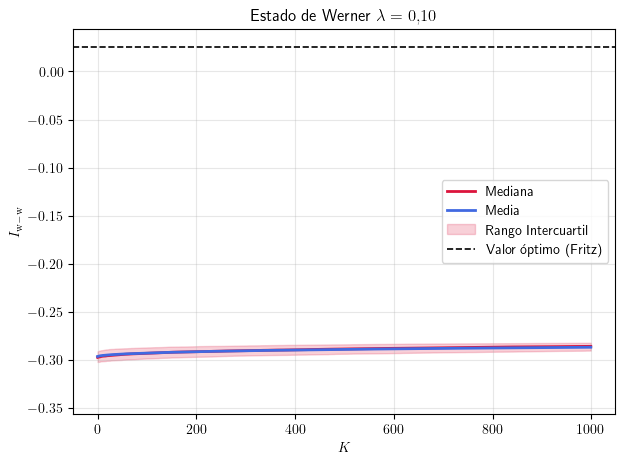

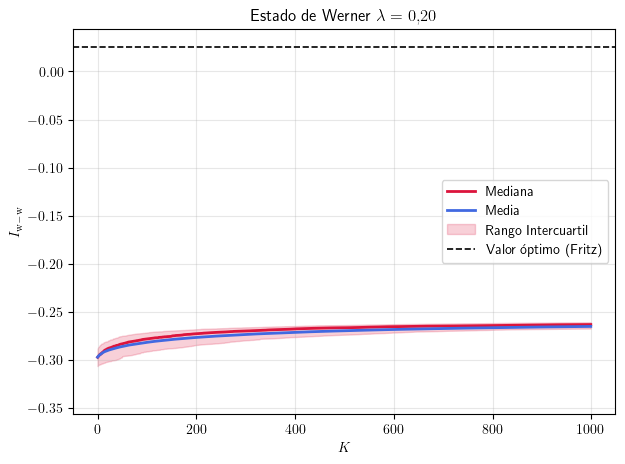

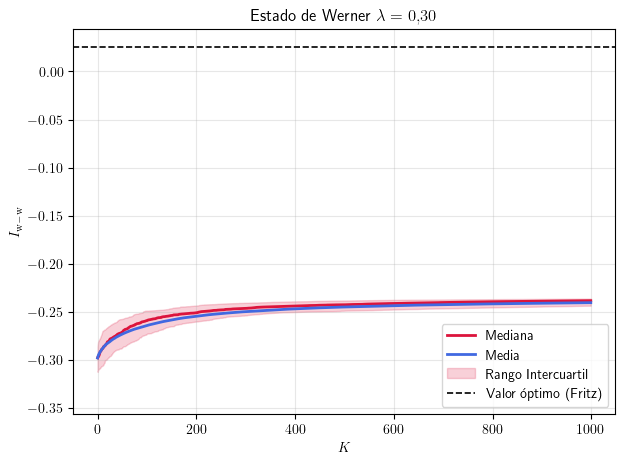

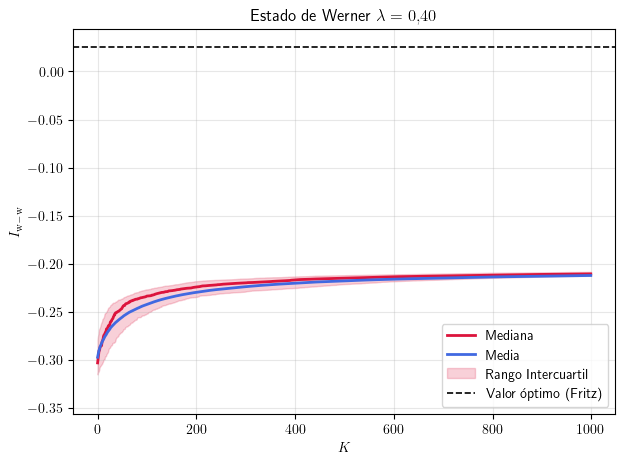

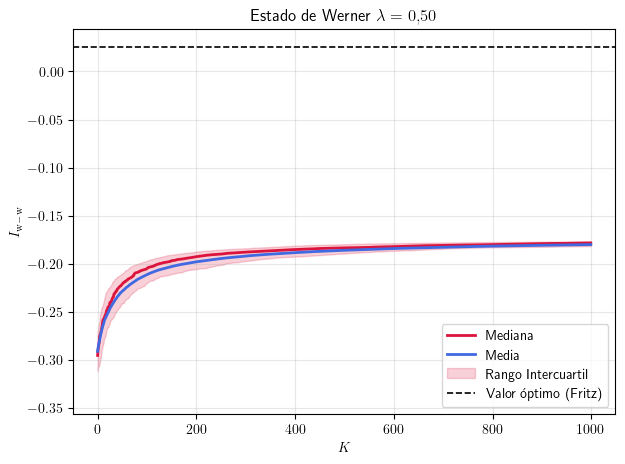

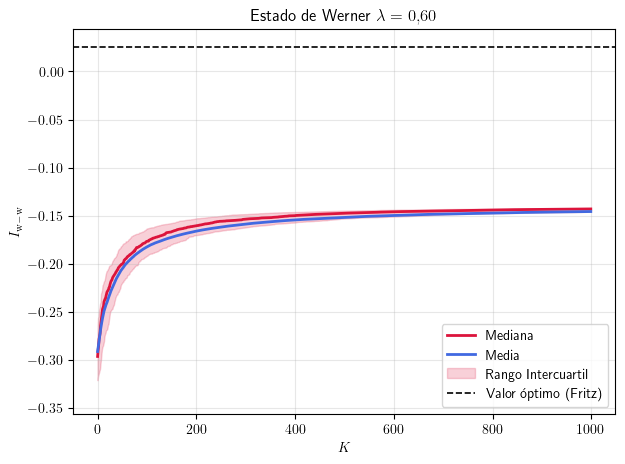

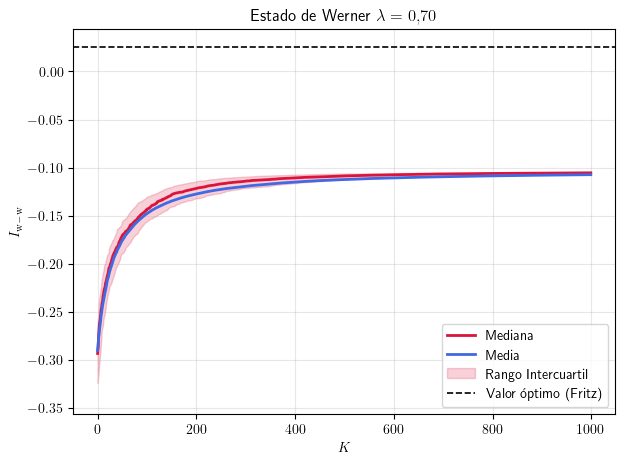

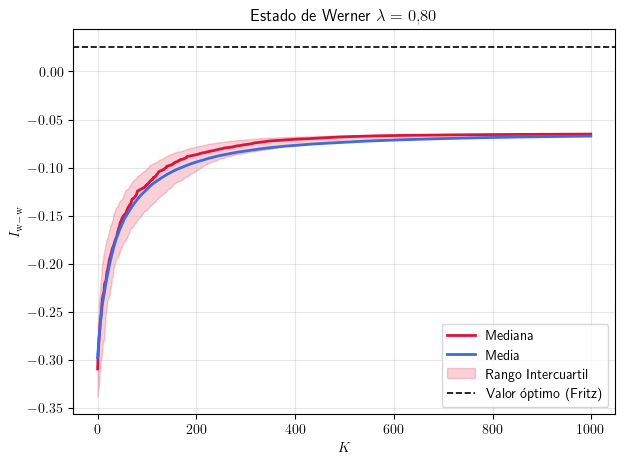

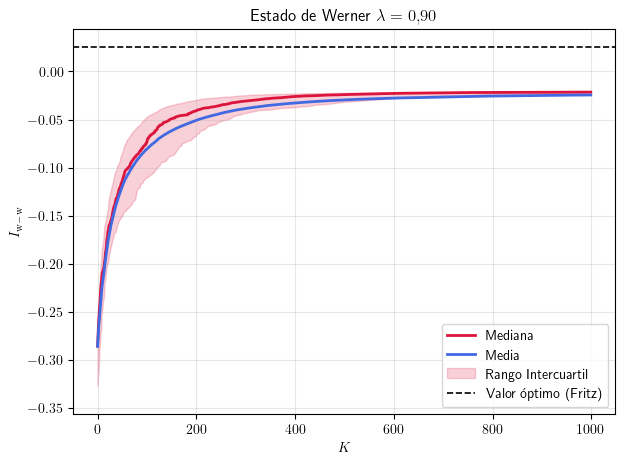

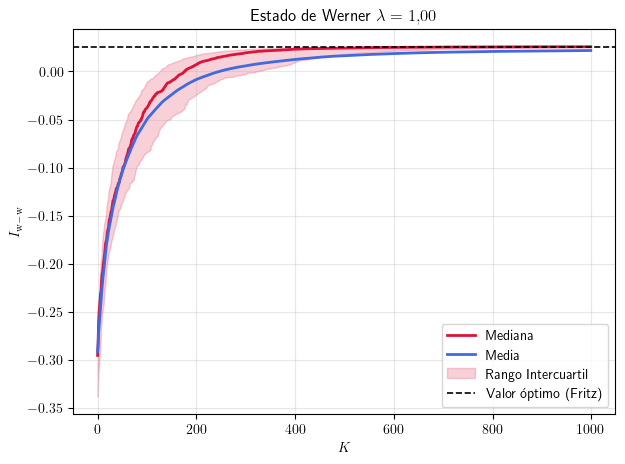

In [12]:
# ==========================================================
# Gráficos — Simulación 01 (los 10 valores de lambda, cada uno independiente)
# ==========================================================
valor_fritz = (np.sqrt(2) - 1) / 16

# --- Escala de referencia, tomada de lambda = 1.0 ---
nombre_ref = f"Sim01_a1.00_{fecha_sim01}.npz"
ruta_ref = os.path.join(carpeta_sim01, nombre_ref)
Data_ref = np.load(ruta_ref)

valores_ref = np.concatenate([Data_ref['mean'], Data_ref['median'],
                               Data_ref['q1'], Data_ref['q3'], [valor_fritz]])
y_min, y_max = valores_ref.min(), valores_ref.max()
margen = 0.05 * (y_max - y_min)
ylim_ref = (y_min - margen, y_max + margen)

for a in valores_a_sim01:
    nombre = f"Sim01_a{a:.2f}_{fecha_sim01}.npz"
    ruta = os.path.join(carpeta_sim01, nombre)
    Data = np.load(ruta)

    mean = Data['mean']
    median = Data['median']
    q1 = Data['q1']
    q3 = Data['q3']
    it = np.arange(len(median))

    plt.figure(figsize=(7,5))

    # Mediana
    plt.plot(it, median, color='crimson', label='Mediana', linewidth=2)

    # Media
    plt.plot(it, mean, color='royalblue', label='Media', linewidth=2)

    # Banda intercuartil (Q1-Q3)
    plt.fill_between(it, q1, q3, color='crimson', alpha=0.2, label='Rango Intercuartil')

    # Valor máximo teórico (distribución de Fritz)
    plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
                label=r'Valor óptimo (Fritz)')

    lambda_str = f"{a:.2f}".replace(".", "{,}")

    plt.xlabel(r"$K$")
    plt.ylabel(r"$I_{\rm w-w}$")
    plt.title(rf"Estado de Werner $\lambda = {lambda_str}$")
    plt.ylim(ylim_ref)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


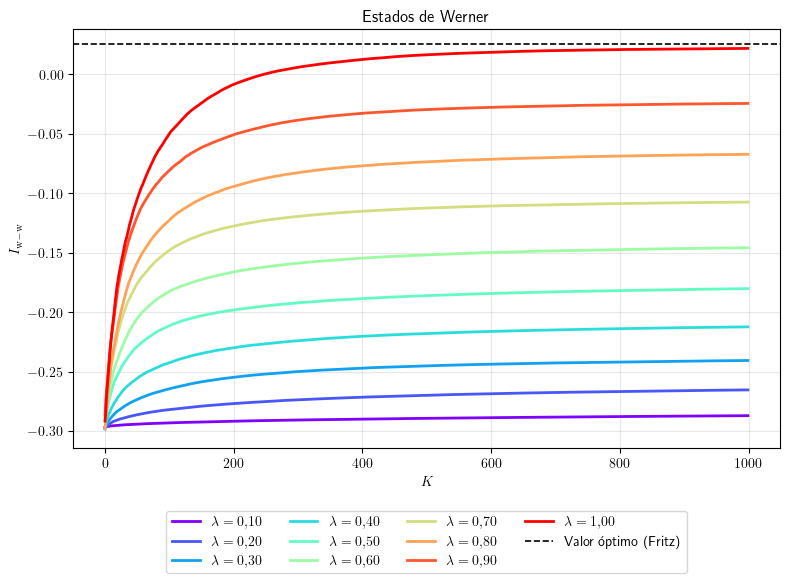

In [ ]:
# ==========================================================
# Gráficos — Simulación 01 (comparación de todos los lambda, medias)
# ==========================================================
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim01)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim01, colors):
    nombre = f"Sim01_a{a:.2f}_{fecha_sim01}.npz"
    ruta = os.path.join(carpeta_sim01, nombre)
    Data = np.load(ruta)
    median = Data['median']

    mean = Data['mean']
    it = np.arange(len(mean))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Estados de Werner")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

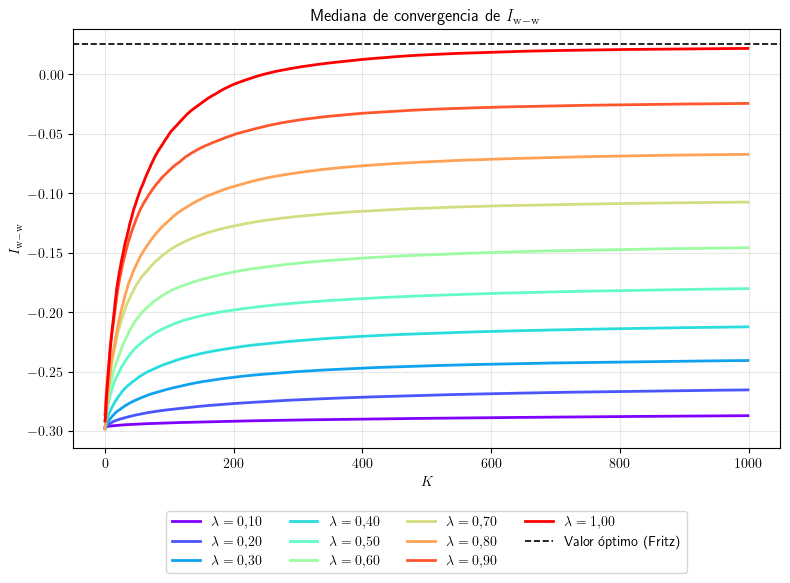

In [13]:
# ==========================================================
# Gráficos — Simulación 01 (comparación de todos los lambda, medias)
# ==========================================================
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim01)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim01, colors):
    nombre = f"Sim01_a{a:.2f}_{fecha_sim01}.npz"
    ruta = os.path.join(carpeta_sim01, nombre)
    Data = np.load(ruta)
    median = Data['median']

    mean = Data['mean']
    it = np.arange(len(mean))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.savefig("Simulacion_01/Sim01_med.pdf")
plt.savefig("Simulacion_01/Sim01_med.png", dpi=600)
plt.tight_layout()
plt.show()

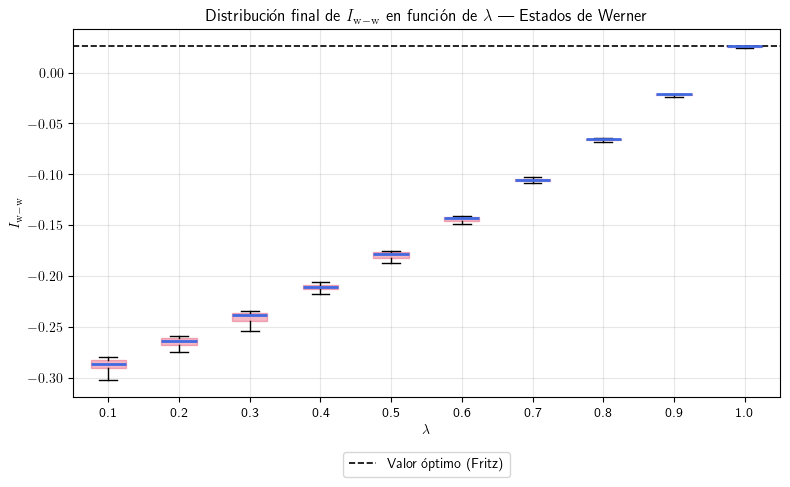

In [18]:
# ==========================================================
# Boxplot — Distribución de I_w-w en la iteración final (K=1000) vs lambda
# ==========================================================
datos_finales = []

for a in valores_a_sim01:
    nombre = f"Sim01_a{a:.2f}_{fecha_sim01}.npz"
    ruta = os.path.join(carpeta_sim01, nombre)
    Data = np.load(ruta)

    Out = Data['Out']
    datos_finales.append(Out[:, -1])   # última iteración (K=1000), 100 realizaciones

plt.figure(figsize=(8,5))

box = plt.boxplot(datos_finales, positions=valores_a_sim01, widths=0.05,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\lambda$ — Estados de Werner")
plt.xticks(valores_a_sim01)
plt.xlim(min(valores_a_sim01) - 0.05, max(valores_a_sim01) + 0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Simulación 02

**Carpeta de datos:** `Simulacion_02`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\lambda$ (parámetro de mezcla de Werner) | $\{0.90,\ 0.91,\ 0.92,\ 0.93,\ 0.94,\ 0.95,\ 0.96,\ 0.97,\ 0.98,\ 0.99,\ 1.00\}$ |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** a diferencia de Simulación 01 (panorama general en pasos
de 0.1 sobre todo el rango de $\lambda$), aquí se hace un barrido fino en
la región de alto entrelazamiento ($\lambda \in [0.90, 1.00]$), con paso
0.01, para observar con mayor resolución cómo se comporta $I_{\rm w-w}$
cerca del estado de Bell puro ($\lambda=1.00$).

**Archivos generados:** `Simulacion_02/Sim02_a{valor}_{fecha}.npz`

In [14]:
# ==========================================================
# Simulación 02 — Ejecución
# ==========================================================
valores_a_sim02 = np.round(np.arange(0.90, 1.001, 0.01), 2).tolist()
max_rep_sim02 = 100
max_iter_sim02 = 1000
gains_sim02 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim02 = "Simulacion_02"
fecha_sim02 = datetime.now().strftime("20260803")

#ejecutar_simulacion(valores_a_sim02, max_rep_sim02, max_iter_sim02,
#                     gains_sim02, "Sim02", carpeta_sim02, fecha_sim02)

In [15]:
import glob

def cargar_ultimo_npz_werner(carpeta, sim_id, a):
    patron = os.path.join(carpeta, f"{sim_id}_a{a:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para a={a:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] a={a:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim02 = "Simulacion_02"
valores_a_sim02 = np.round(np.arange(0.90, 1.001, 0.01), 2).tolist()

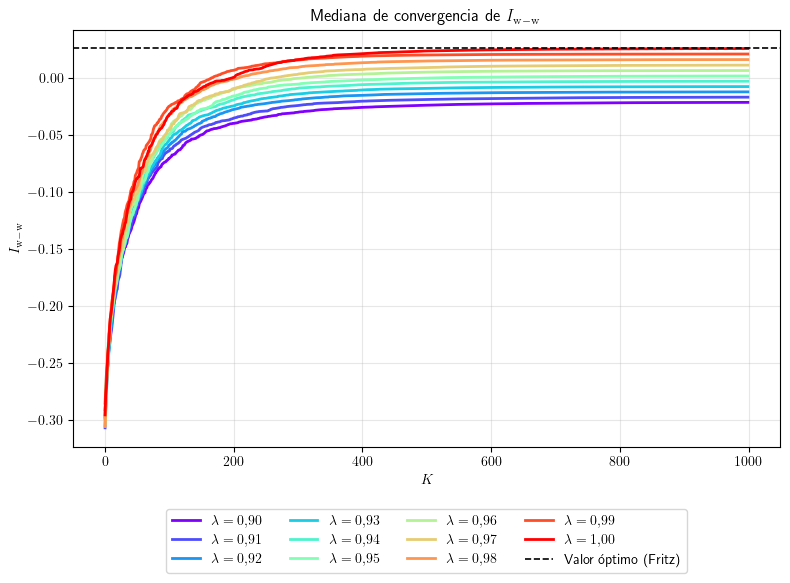

In [23]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim02)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim02, colors):
    Data = cargar_ultimo_npz_werner(carpeta_sim02, "Sim02", a)
    median = Data['median']
    it = np.arange(len(median))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_02/Sim02_med_02.pdf")
plt.savefig("Simulacion_02/Sim02_med_02.png", dpi=600)

plt.show()

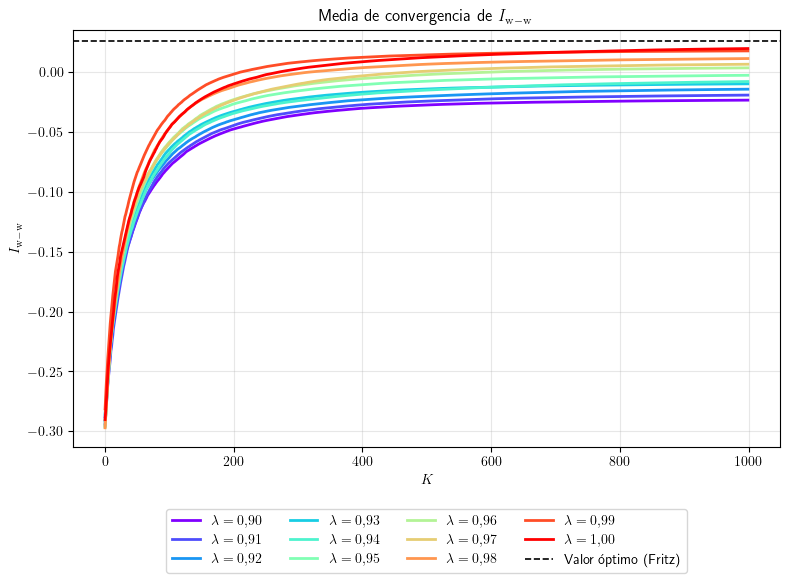

In [ ]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim02)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim02, colors):
    Data = cargar_ultimo_npz_werner(carpeta_sim02, "Sim02", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_02/Sim02_mean.pdf")
plt.savefig("Simulacion_02/Sim02_mean.png", dpi=600)

plt.show()

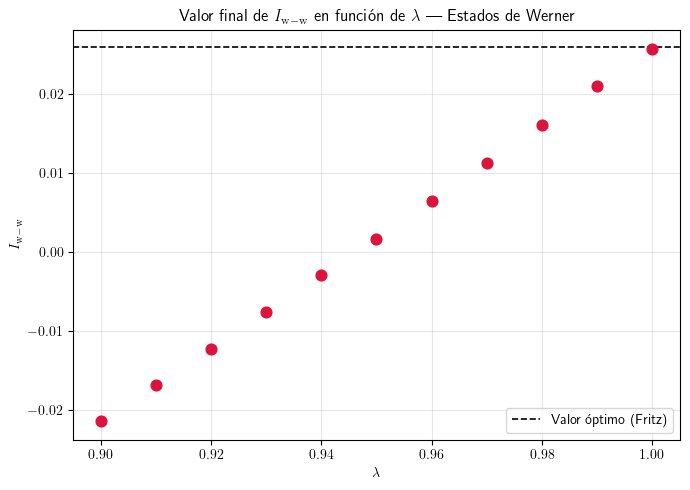

In [24]:
medianas_finales = []

for a in valores_a_sim02:
    Data = cargar_ultimo_npz_werner(carpeta_sim02, "Sim02", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(valores_a_sim02, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\lambda$ — Estados de Werner")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

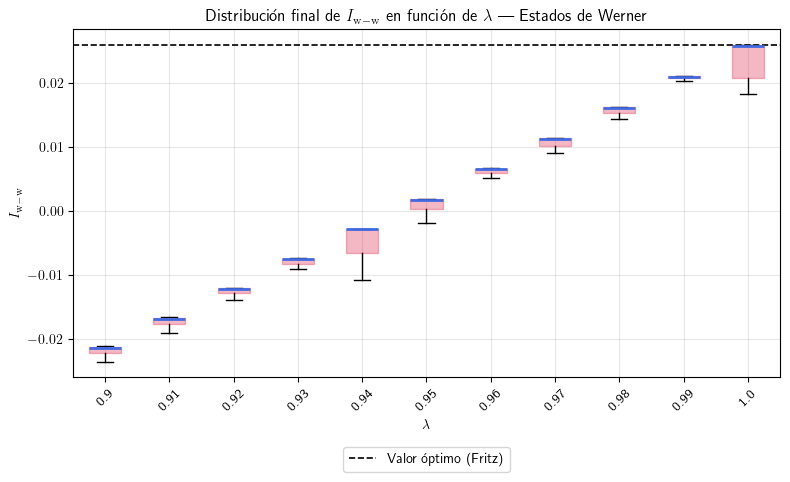

In [25]:
datos_finales = []

for a in valores_a_sim02:
    Data = cargar_ultimo_npz_werner(carpeta_sim02, "Sim02", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=valores_a_sim02, widths=0.005,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\lambda$ — Estados de Werner")
plt.xticks(valores_a_sim02, rotation=45)
plt.xlim(min(valores_a_sim02) - 0.005, max(valores_a_sim02) + 0.005)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Simulación 03

**Carpeta de datos:** `Simulacion_03`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\lambda$ (fuente variable) | $\{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5,\ 0.6,\ 0.7,\ 0.8,\ 0.9,\ 1.0\}$ |
| Fuentes fijas (las otras dos) | $\lambda=0$ (separables, estado maximamente mixto) |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** siguiendo la misma estrategia usada en Schmidt (Simulación 03),
aquí solo una fuente tiene el parámetro de mezcla de Werner variable; las
otras dos fuentes quedan fijas en $\lambda=0$ (estado maximamente mixto,
separable). El objetivo es aislar el efecto de una sola fuente "ruidosa"
sobre $I_{\rm w-w}$, en vez de aplicar el mismo $\lambda$ simétricamente a
las tres fuentes como en Simulación 01 y 02.

**Archivos generados:** `Simulacion_03/Sim03_a{valor}_{fecha}.npz`

In [26]:
def construir_rho_werner_fuentes(lambdas_fuentes):
    """
    Construye la matriz densidad de la red triangular donde cada una de
    las tres fuentes (alpha, beta, gamma, en ese orden) tiene su propio
    parámetro de mezcla de Werner. lambdas_fuentes = [lam_alpha, lam_beta, lam_gamma].
    Con lam=0, la fuente correspondiente es separable (estado maximamente mixto).

    Nota de notación: cada `lam` corresponde a \\lambda en las gráficas y
    en el texto de la tesis; se mantiene como variable `lam`/`a` en el
    código por simplicidad.
    """
    psi = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
    rhos = []
    for lam in lambdas_fuentes:
        rho = lam*np.outer( psi, psi.conj() ) + (1-lam)*np.eye(4)/4
        rhos.append(rho)

    Rho = triple_kron( rhos[0], rhos[1], rhos[2] )
    Rho = Rho.reshape(2*6*[2]).transpose(
            [ 5,0,2,1,4,3, 11,6,8,7,10,9 ]).reshape(2**6, 2**6)
    return Rho


def _una_repeticion_sim03(lambda_variable, gains, max_iter):
    """
    Una repetición de CSPSA para Simulación 03 (Werner): solo la fuente
    'alpha' varía; 'beta' y 'gamma' quedan fijas en lambda=0 (separables).
    """
    Rho = construir_rho_werner_fuentes([lambda_variable, 0.0, 0.0])

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Rho),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion_sim03(valores_a, max_rep, max_iter, gains, sim_id, carpeta_sim,
                               fecha=None, n_jobs=-1):
    """
    Igual que ejecutar_simulacion, pero para el escenario asimétrico:
    solo una fuente varía en lambda, las otras dos quedan fijas en 0
    (separables, estado maximamente mixto).
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in valores_a:
        print(f"[{sim_id}] a = {a:.2f}  (paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

        resultados = Parallel(n_jobs=n_jobs)(
            delayed(_una_repeticion_sim03)(a, gains, max_iter) for _ in range(max_rep)
        )
        Out = np.array(resultados)

        nombre = f"{sim_id}_a{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)

        np.savez(ruta,
                 Out=Out,
                 mean=Out.mean(axis=0),
                 median=np.median(Out, axis=0),
                 q1=np.percentile(Out, 25, axis=0),
                 q3=np.percentile(Out, 75, axis=0),
                 a=a, gains=gains, max_iter=max_iter,
                 max_rep=max_rep, sim_id=sim_id, fecha=fecha)

        print(f"  Guardado: {ruta}")

In [ ]:
# ==========================================================
# Simulación 03 — Ejecución
# ==========================================================
valores_a_sim03 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
max_rep_sim03 = 100
max_iter_sim03 = 1000
gains_sim03 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim03 = "Simulacion_03"
fecha_sim03 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion_sim03(valores_a_sim03, max_rep_sim03, max_iter_sim03,
#                           gains_sim03, "Sim03", carpeta_sim03, fecha_sim03)

[Sim03] a = 0.00  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.00_20260804.npz
[Sim03] a = 0.10  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.10_20260804.npz
[Sim03] a = 0.20  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.20_20260804.npz
[Sim03] a = 0.30  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.30_20260804.npz
[Sim03] a = 0.40  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.40_20260804.npz
[Sim03] a = 0.50  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.50_20260804.npz
[Sim03] a = 0.60  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.60_20260804.npz
[Sim03] a = 0.70  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.70_20260804.npz
[Sim03] a = 0.80  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0

In [ ]:
# ==========================================================
# Simulación 03 — Ejecución
# ==========================================================
valores_a_sim03 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
max_rep_sim03 = 100
max_iter_sim03 = 1000
gains_sim03 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim03 = "Simulacion_03"
fecha_sim03 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion_sim03(valores_a_sim03, max_rep_sim03, max_iter_sim03,
#                           gains_sim03, "Sim03", carpeta_sim03, fecha_sim03)

[Sim03] a = 0.00  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.00_20260804.npz
[Sim03] a = 0.10  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.10_20260804.npz
[Sim03] a = 0.20  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.20_20260804.npz
[Sim03] a = 0.30  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.30_20260804.npz
[Sim03] a = 0.40  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.40_20260804.npz
[Sim03] a = 0.50  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.50_20260804.npz
[Sim03] a = 0.60  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.60_20260804.npz
[Sim03] a = 0.70  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0.70_20260804.npz
[Sim03] a = 0.80  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_a0

In [29]:
import glob

def cargar_ultimo_npz_werner(carpeta, sim_id, a):
    patron = os.path.join(carpeta, f"{sim_id}_a{a:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para a={a:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] a={a:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim03 = "Simulacion_03"
valores_a_sim03 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

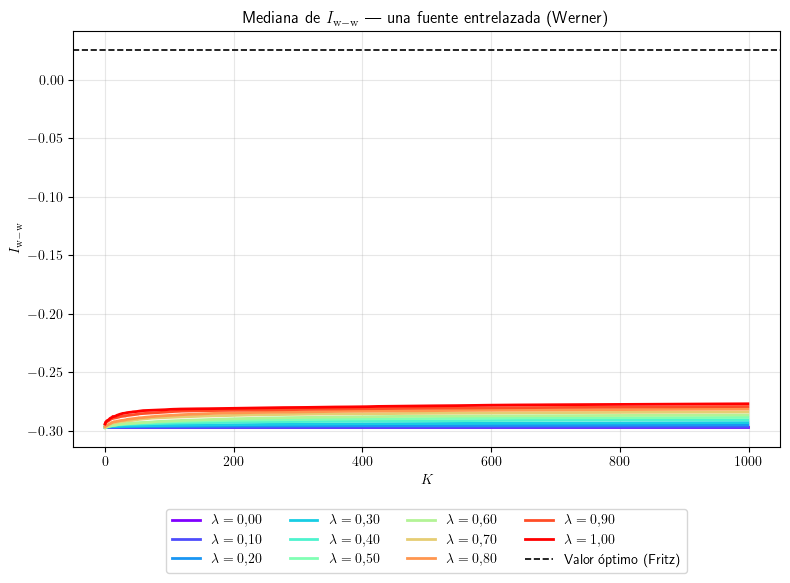

In [30]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim03)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim03, colors):
    Data = cargar_ultimo_npz_werner(carpeta_sim03, "Sim03", a)
    median = Data['median']
    it = np.arange(len(median))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de $I_{\rm w-w}$ — una fuente entrelazada (Werner)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

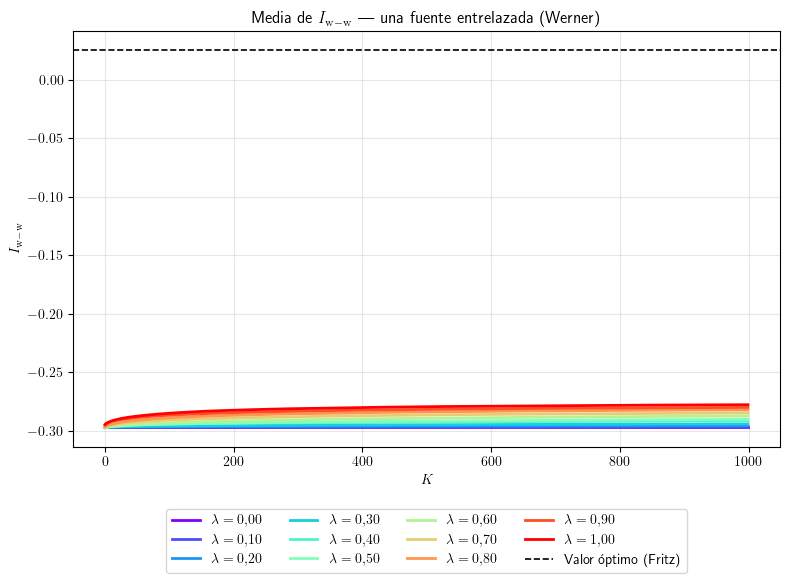

In [31]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim03)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim03, colors):
    Data = cargar_ultimo_npz_werner(carpeta_sim03, "Sim03", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de $I_{\rm w-w}$ — una fuente entrelazada (Werner)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

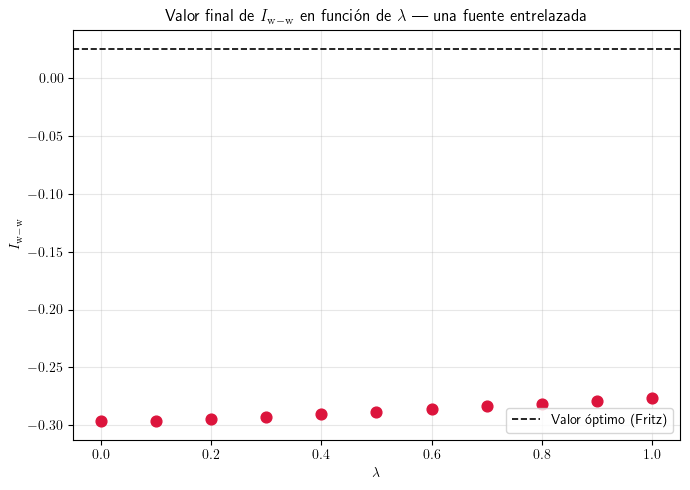

In [32]:
medianas_finales = []

for a in valores_a_sim03:
    Data = cargar_ultimo_npz_werner(carpeta_sim03, "Sim03", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(valores_a_sim03, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\lambda$ — una fuente entrelazada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

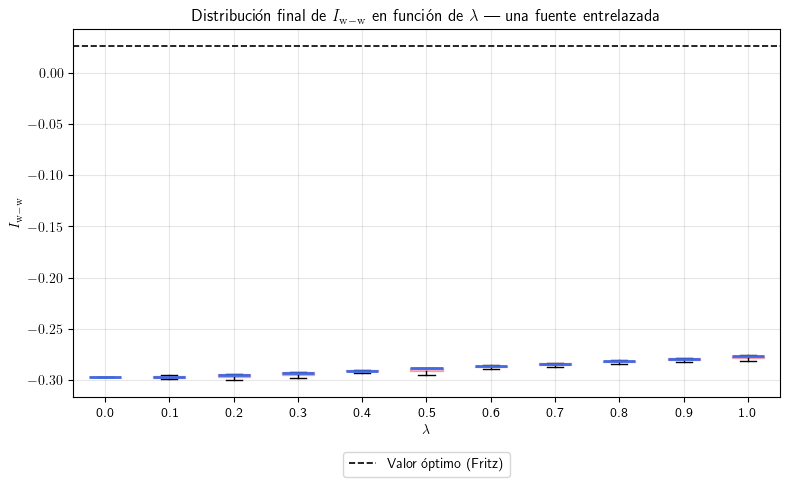

In [33]:
datos_finales = []

for a in valores_a_sim03:
    Data = cargar_ultimo_npz_werner(carpeta_sim03, "Sim03", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=valores_a_sim03, widths=0.05,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\lambda$ — una fuente entrelazada")
plt.xticks(valores_a_sim03)
plt.xlim(min(valores_a_sim03) - 0.05, max(valores_a_sim03) + 0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Simulación 04

**Carpeta de datos:** `Simulacion_04`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\lambda$ (dos fuentes variables, mismo valor) | $\{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5,\ 0.6,\ 0.7,\ 0.8,\ 0.9,\ 1.0\}$ |
| Fuente fija (la tercera) | $\lambda=0$ (separable, estado maximamente mixto) |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** a diferencia de Simulación 03 (una sola fuente entrelazada),
aquí dos fuentes comparten el mismo parámetro de mezcla de Werner variable,
mientras la tercera queda fija en $\lambda=0$ (separable). El objetivo es
observar el efecto de tener dos fuentes "ruidosas" simultáneamente sobre
$I_{\rm w-w}$, siguiendo la misma estrategia usada en Schmidt (Simulación 04).

**Archivos generados:** `Simulacion_04/Sim04_a{valor}_{fecha}.npz`

In [34]:
def _una_repeticion_sim04(lambda_variable, gains, max_iter):
    """
    Una repetición de CSPSA para Simulación 04 (Werner): las fuentes
    'alpha' y 'beta' comparten el mismo parámetro de mezcla variable;
    'gamma' queda fija en lambda=0 (separable).
    """
    Rho = construir_rho_werner_fuentes([lambda_variable, lambda_variable, 0.0])

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Rho),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion_sim04(valores_a, max_rep, max_iter, gains, sim_id, carpeta_sim,
                               fecha=None, n_jobs=-1):
    """
    Igual que ejecutar_simulacion_sim03, pero para el escenario donde
    dos fuentes (alpha, beta) varían juntas con el mismo valor, y la
    tercera (gamma) queda fija en 0 (separable).
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in valores_a:
        print(f"[{sim_id}] a = {a:.2f}  (paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

        resultados = Parallel(n_jobs=n_jobs)(
            delayed(_una_repeticion_sim04)(a, gains, max_iter) for _ in range(max_rep)
        )
        Out = np.array(resultados)

        nombre = f"{sim_id}_a{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)

        np.savez(ruta,
                 Out=Out,
                 mean=Out.mean(axis=0),
                 median=np.median(Out, axis=0),
                 q1=np.percentile(Out, 25, axis=0),
                 q3=np.percentile(Out, 75, axis=0),
                 a=a, gains=gains, max_iter=max_iter,
                 max_rep=max_rep, sim_id=sim_id, fecha=fecha)

        print(f"  Guardado: {ruta}")

In [17]:
# ==========================================================
# Simulación 04 — Ejecución
# ==========================================================
valores_a_sim04 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
max_rep_sim04 = 100
max_iter_sim04 = 1000
gains_sim04 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim04 = "Simulacion_04"
fecha_sim04 = datetime.now().strftime("20260803")

#ejecutar_simulacion_sim04(valores_a_sim04, max_rep_sim04, max_iter_sim04,
#                           gains_sim04, "Sim04", carpeta_sim04, fecha_sim04)

In [18]:
import glob

def cargar_ultimo_npz_werner(carpeta, sim_id, a):
    patron = os.path.join(carpeta, f"{sim_id}_a{a:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para a={a:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] a={a:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim04 = "Simulacion_04"
valores_a_sim04 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

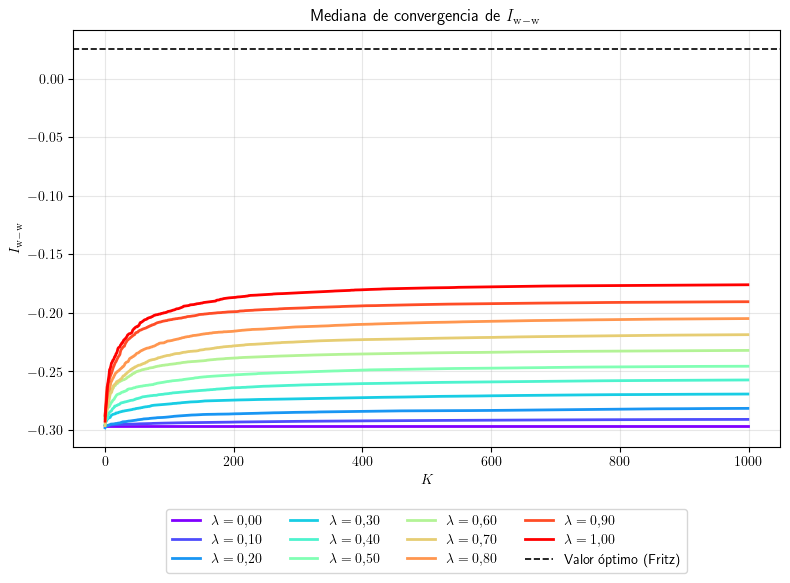

In [20]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim04)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim04, colors):
    Data = cargar_ultimo_npz_werner(carpeta_sim04, "Sim04", a)
    median = Data['median']
    it = np.arange(len(median))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_04/Sim04_med.pdf")
plt.savefig("Simulacion_04/Sim04_med.png", dpi=600)

plt.show()

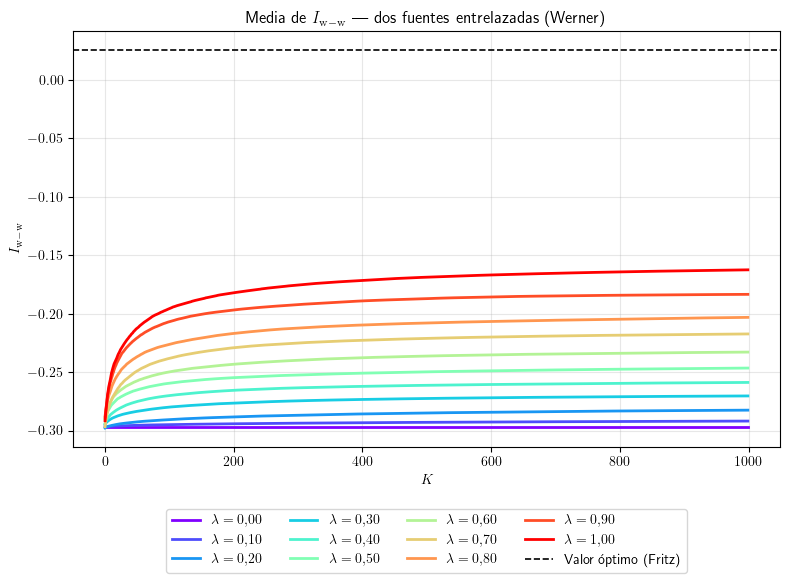

In [38]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(valores_a_sim04)))

plt.figure(figsize=(8,6))

for a, color in zip(valores_a_sim04, colors):
    Data = cargar_ultimo_npz_werner(carpeta_sim04, "Sim04", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    lambda_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\lambda = {lambda_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de $I_{\rm w-w}$ — dos fuentes entrelazadas (Werner)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

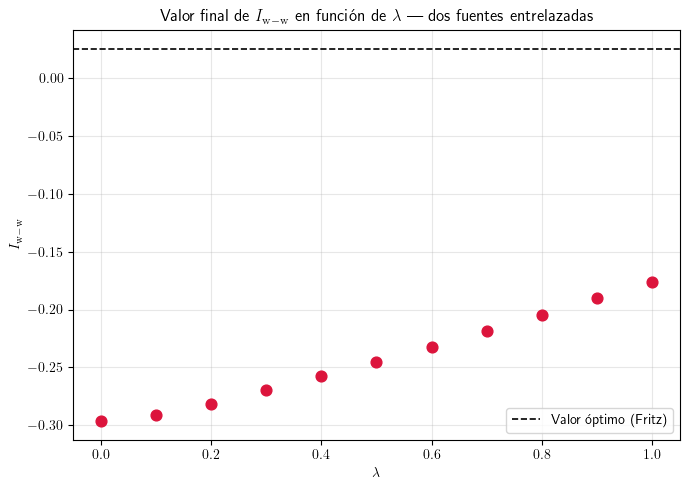

In [39]:
medianas_finales = []

for a in valores_a_sim04:
    Data = cargar_ultimo_npz_werner(carpeta_sim04, "Sim04", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(valores_a_sim04, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\lambda$ — dos fuentes entrelazadas")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

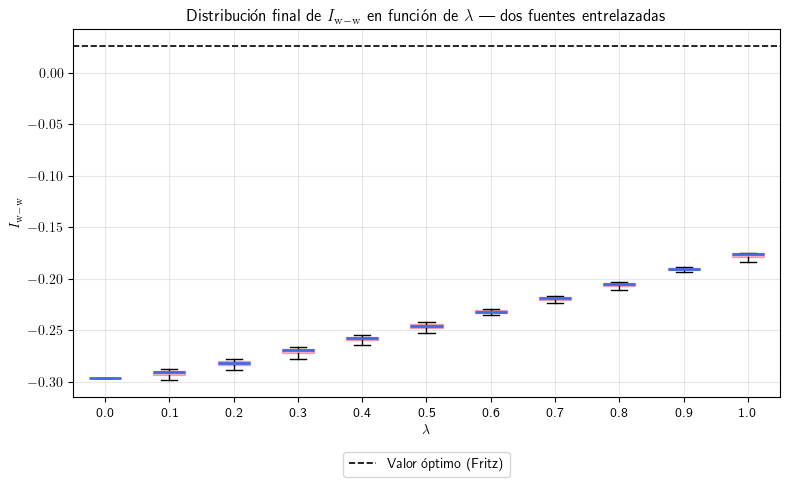

In [40]:
datos_finales = []

for a in valores_a_sim04:
    Data = cargar_ultimo_npz_werner(carpeta_sim04, "Sim04", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=valores_a_sim04, widths=0.05,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\lambda$ — dos fuentes entrelazadas")
plt.xticks(valores_a_sim04)
plt.xlim(min(valores_a_sim04) - 0.05, max(valores_a_sim04) + 0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()